# Markov Chain

A Markov Chain is a stochastic mathematical model that describes a sequence of possible events.
The core principle is that "The future depends only on the present, not on the past."

💡 **Hint:**  Knowing the status of "today" is completely sufficient to predict "tomorrow". The data from "yesterday" adds no extra predictive power.

## Mathematical Definition

Let $X_{t}$ be a random variable representing the state of a system at time $t$. If the process follows a Markov Chain, its conditional probability is defined as:
$$ P(X_{t+1} | X_t = x_t, X_{t-1} = x_{t-1}, ... X_{0} = x_{0}) = P(X_{t+1} | X_t = x_t) $$


<!-- ### Start State Matrix -->
<!-- $$ Start State = [P_0, P_1, ..., P_{n-1}] $$
Where -->

### State Transition Matrix
For a system with $n$ possible states, we use an $n \times n$ matrix $P$ to represent the probabilities of moving from one state to another. This is called the **Transition Matrix**.

$$ P = \begin{bmatrix}
P_{0,0} & P_{0,1} & ... & P_{0,n-1} \\
P_{1,0} & P_{1,1} & ... & P_{1,n-1} \\
\vdots & \vdots &  & \vdots \\
P_{n-1,0} & P_{n-1,1} & ... & P_{n-1,n-1} \\
\end{bmatrix} $$

Where
- Each element $P_{i,j}$ represents the$ probability of transitioning from state $i$ to state $j$.
- For all $i$ and $j$, $p_{i,j} \ge 0$.
- The sum of each row must equal 1: $\sum_{j} P_{i,j} = 1$.





In [58]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from typing import Literal

## Sequence Generator

Use Markov chain to generate a sequence

**Tasks**
1. Create a `states`
2. Create a `transition` metrix
3. Generate a sequence 

In [55]:
def gen_seq(
    states: list[str],
    start: NDArray[np.float64],
    transition: NDArray[np.float64],
    length: int,
) -> str:
    idx_list = [i for i in range(len(states))]
    current_idx = np.random.choice(idx_list, p=start)
    out_seq = states[current_idx]

    for _ in range(length - 1):
        prob = transition[current_idx]
        current_idx = np.random.choice(idx_list, p=prob)
        out_seq += states[current_idx]
    return out_seq


def count_kmer(seq: str, kmer: str) -> int:
    if len(seq) < len(kmer):
        return 0
    return seq.count(kmer)

#### Example 1
A DNA sequence contains A and T, assume that:
- If current position is A, the likelihood that next position is A is 60%
- If current position is T, the likelihood that next position is A is 30%

Try to generate a sequence

In [45]:
states = ["A", "C"]
start = np.array([0.5, 0.5])
transition = np.array(
    [
        [0.6, 0.4],  # A -> A, C
        [0.3, 0.7],  # C -> A, C
    ]
)
print(f"Generated Seq: {gen_seq(states, start, transition, 50)}")

Generated Seq: CCAAAACCCACAAAACCACCAAACCCCCCCAACCCCCCAACCCAACCCAA


#### Example 2 

Generate a general DNA sequence contains A, T, G, and C.

In [46]:
states = ["A", "C", "T", "G"]
start = np.array([0.2, 0.3, 0.2, 0.3])
transition = np.array(
    [
        [0.2, 0.3, 0.3, 0.2],  # A -> A, C, T, G
        [0.1, 0.3, 0.5, 0.1],  # C -> A, C, T, G
        [0.2, 0.3, 0.3, 0.2],  # T -> A, C, T, G
        [0.2, 0.3, 0.3, 0.2],  # G -> A, C, T, G
    ]
)
print(f"Generated Seq: {gen_seq(states, start, transition, 50)}")

Generated Seq: CTTCCTTGTGTGACCTTGTTTCGCTATGTGGACCTATTTCTATCCGTCTG


#### Example 3

Generate a CAG repeat intensive sequence.

In [ ]:
### For CAG repeat intensive region
states = ["A", "C", "T", "G"]
start = np.array([0.2, 0.3, 0.2, 0.3])
transition = np.array(
    [
        [0.05, 0.1, 0.05, 0.8],  # A -> A, C, T, G
        [0.8, 0.05, 0.1, 0.05],  # C -> A, C, T, G
        [0.2, 0.3, 0.3, 0.2],  # T -> A, C, T, G
        [0.05, 0.8, 0.05, 0.1],  # G -> A, C, T, G
    ]
)
seq = gen_seq(states, start, transition, 1000)
count = count_kmer(seq, "CAG")
print(f"Generated Seq with {count} of CAG repeat: {seq}")

Generated Seq with 204 of CAG repeat: AGCAGCGCAGCAGCAGCTCCAGCAGGCCTAGCAGGGGCAGGCAGCAAGCAGCAGCGAGGCAGGCAGCAAGCAGCAGCACAGAGCACAGCAGCAGCATCACAGCAGCACAGCTCAGAGCAGCTTTGGCAGCTCGAAGCAGCAGTGCAGCAGCACAGCAGCTTGCAGCTTTCAGCAGCGCAGAGCAGCAGCAGCACAGCACGGCAGCAGTTAGCAGCTGCAGCAGCAGCACAGCAGAGCTAGCAGCAGCAGCTGGAGCACAGCAGCAGCATGCAGCACCAGCAAAGCAGAGCAGTCACACAGCAGCAAGCCAGCAGCAGCAGCAGCAGCAGAGCAGCAGCACAGCTCAGTTCTACAGGCAGCAGCACAGCGAGCAGCAGGCAGCTGGGCAAGCATGCAGCGCAGCAAGAGGCAGCGCAGCAGCAGGCCGCAAGCAGCTCAGCAAGCTCAGGCAGCAGCTCCAGCAGCAGCAGCAGCAGCAAGCAGTCAGCACTGGCAGCTGCAGCGCCTTCACAGCAGCAGCAACTTGCATTTCACAGCAGGCAGGCCAGCTTCCAGGCAGCAGTGCCGCAGGCAGCAGCAAGCCAGGCAGCAGCAGCAGCAGTAGCAGGCAGCAGCAGCAGGGCACAGCAAAGCACAAGCAGCAGCAGGCAGCTTCAAGAGGCAGCAGCTTTGCAGCAGCAGCAGCCAGCAGCAGCAGCAGCAGAGCAGCAGCAGAGGCAGCTTGGCAGGCAGTCAGCAGCAGGCAGCAGCAGCACATAGCCAGGCAGCCAGCAAGCAGCAGCACAGCAGCAGCGCTGCAGCAGCAGCAGCAGAGCAGCGCGCATAGCACAGCAGAGCAGCCAGCAGCAGCAGGCCAGCAGGGGCAGGCAGCCTAGCAGCAGCAGCAGCTAGCTAGCAGCATCAGTAGCAGCAGCGCAGCAGCTTCAGTGCAGCAGCACTGCTCAGCAGGCAGCAGCAGCACA

## Estimate Transition Matrix
Given a list of AC sequence, how to estimate the transition matrix?

**Tasks**
1. Generate a list of AC sequence from `gen_ac_seq` function.
2. Estimate the transition matrix by computing the frequencies of the sequence.
3. Compare results across different sizes.


In [47]:
def estimate_start(nc_map: dict[str, int], samples: list[str]) -> NDArray[np.float64]:
    count_start = np.zeros(len(nc_map))
    indexs = [nc_map.get(s[0]) for s in samples]
    np.add.at(count_start, indexs, 1)
    total = max(count_start.sum(), 1)
    return count_start / total


def estimate_transition(
    nc_map: dict[str, int], samples: list[str]
) -> NDArray[np.float64]:
    size = len(nc_map)
    count_transition = np.zeros((size, size))
    for seq in samples:
        sidx = np.array([nc_map.get(s) for s in seq])
        current_indices = sidx[:-1]
        next_indices = sidx[1:]
        np.add.at(count_transition, (current_indices, next_indices), 1)
    row_sums = count_transition.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return count_transition / row_sums

## Evaluate Transmition Matrices

### Evaluation approaches
- **Frobenius Norm**: 
    This is the most standard way to measure the distance between two matrices. It subtracts the two matrices element-by-element, squares the differences, sums them up, and takes the square root.

    $$  Frobenius_Norm = \sqrt{ \sum_{i,j} \big(P_{true}(i,j) - P_{est} (i,j)\big)^2 } $$

    Closer to 0 means higher accuracy.<br><br><br>


- **Mean Absolute Error (MAE)**:
    It calculates the absolute difference between every corresponding cell in $P_{true}$ and $P_{est}$, then takes the average.

    $$ MAE = \frac{1}{n} \sum_{i,j} \big| P_{true}(i,j) - P_{est} (i,j)\big|  $$

    Closer to 0 means higher accuracy.<br><br><br>


- **Kullback-Leibler Divergence**: 
    In information theory and Markov chain literature, KL divergence measures how much information is lost when we use $P_{est}$ to approximate $P_{true}$. You calculate the KL divergence for each row (since each row is a probability distribution) and average them.

    $$ D_{\text{KL}} (P_{true} \parallel P_{est}) = \sum_{i,j} \log P_{true}(i,j) \frac{ P_{true}(i,j) }{ P_{est}(i,j)} $$

    Closer to 0 means higher accuracy.<br><br><br>

In [48]:
def evaluate_matrix_accuracy(
    p_true: NDArray[np.float64],
    p_est: NDArray[np.float64],
    method: Literal["fro", "mae", "kld"] = "fro",
) -> float:

    if method not in ["fro", "mae", "kld"]:
        raise ValueError("Only support methods 'fro', 'mae', 'kld'.")

    elif method == "fro":
        # Frobenius Norm
        return np.linalg.norm(p_true - p_est)

    elif method == "mae":
        # Mean Absolute Error, MAE
        return np.mean(np.abs(p_true - p_est))

    else:
        # Kullback-Leibler Divergence
        calc_axis = 1 if p_true.ndim == 2 else 0
        eps = 1e-10
        kl_per_row = np.sum(
            p_true * np.log((p_true + eps) / (p_est + eps)), axis=calc_axis
        )
        return np.mean(kl_per_row)

### Convergence Testing for transition matrix

Verify the accuracy of the estimated transition matrix against the true matrix using the generated Markov chain sequence data.

**Tasks**:
1. Generate sequence data given a transition matrix.
2. Estimate transition matrix by the data generated.
3. Using the evaluation approaches above to verify the accuracy of the estimated result.
4. Draw a plot.

In [66]:
def run_test(
    states: list[str],
    start: NDArray[np.float64],
    transition: NDArray[np.float64],
    seq_size: int,
    sample_size: int,
    method: Literal["fro", "mae", "kld"] = "fro",
):
    if method not in ["fro", "mae", "kld"]:
        raise ValueError("Only support methods 'fro', 'mae', 'kld'.")

    seqs = [gen_seq(states, start, transition, seq_size) for _ in range(sample_size)]
    nc_map = {key: idx for idx, key in enumerate(states)}
    est_transition = estimate_transition(nc_map, seqs)
    accuracy = evaluate_matrix_accuracy(transition, est_transition, method)
    return accuracy


states = ["A", "C", "T", "G"]
start = np.array([0.2, 0.3, 0.2, 0.3])
transition = np.array(
    [
        [0.2, 0.3, 0.3, 0.2],  # A -> A, C, T, G
        [0.1, 0.3, 0.5, 0.1],  # C -> A, C, T, G
        [0.2, 0.3, 0.3, 0.2],  # T -> A, C, T, G
        [0.2, 0.3, 0.3, 0.2],  # G -> A, C, T, G
    ]
)


def draw_validation(sample_size: int, seq_sizes: list[int]):
    fro = [
        run_test(states, start, transition, size, sample_size, method="fro")
        for size in seq_sizes
    ]
    mae = [
        run_test(states, start, transition, size, sample_size, method="mae")
        for size in seq_sizes
    ]
    kld = [
        run_test(states, start, transition, size, sample_size, method="kld")
        for size in seq_sizes
    ]

    plt.figure(figsize=(10, 6))
    plt.plot(
        seq_sizes,
        fro,
        marker="o",
        color="blue",
        linewidth=2,
        label="Frobenius Distance",
    )
    plt.plot(
        seq_sizes,
        mae,
        marker="o",
        color="orange",
        linewidth=2,
        label="Mean Absolute Error (MAE)",
    )
    plt.plot(
        seq_sizes, kld, marker="o", color="green", linewidth=2, label="KL Divergence"
    )
    plt.title(
        "Markov Chain Matrix Convergence Analysis", fontsize=14, fontweight="bold"
    )
    plt.xlabel("Sequence Length (bp)", fontsize=12)
    plt.ylabel("Error Value", fontsize=12)
    plt.xscale("log")
    plt.grid(True, which="both", linestyle=":", alpha=0.6)
    plt.legend(fontsize=11)
    plt.show()

#### Example 1:
Generate transition matrix.

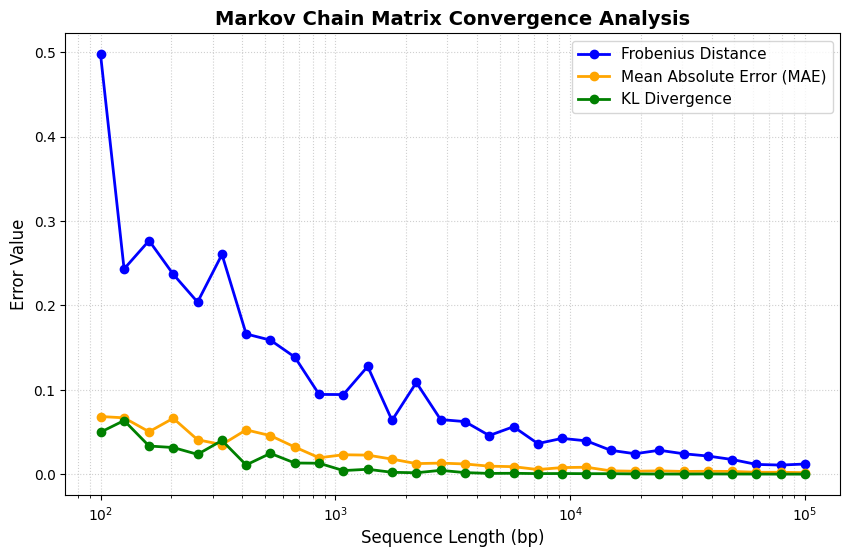

In [65]:
states = ["A", "C", "T", "G"]
start = np.array([0.2, 0.3, 0.2, 0.3])
transition = np.array(
    [
        [0.2, 0.3, 0.3, 0.2],  # A -> A, C, T, G
        [0.1, 0.3, 0.5, 0.1],  # C -> A, C, T, G
        [0.2, 0.3, 0.3, 0.2],  # T -> A, C, T, G
        [0.2, 0.3, 0.3, 0.2],  # G -> A, C, T, G
    ]
)
sample_size = 1
seq_sizes = np.geomspace(100, 100000, num=30, dtype=int)

draw_validation(sample_size, seq_sizes)

#### Example 2:
CAG repeat intensive sequence.


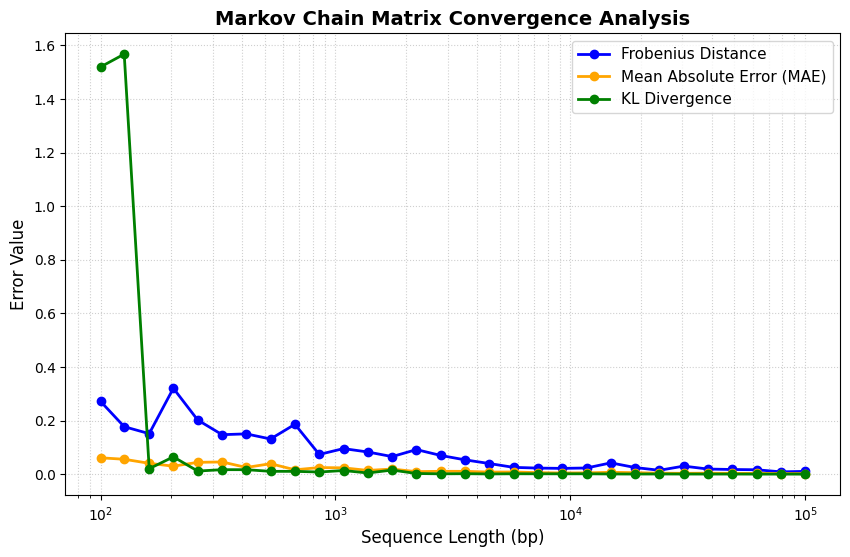

In [67]:
states = ["A", "C", "T", "G"]
start = np.array([0.2, 0.3, 0.2, 0.3])
transition = np.array(
    [
        [0.05, 0.1, 0.05, 0.8],  # A -> A, C, T, G
        [0.8, 0.05, 0.1, 0.05],  # C -> A, C, T, G
        [0.2, 0.3, 0.3, 0.2],  # T -> A, C, T, G
        [0.05, 0.8, 0.05, 0.1],  # G -> A, C, T, G
    ]
)
sample_size = 1
seq_sizes = np.geomspace(100, 100000, num=30, dtype=int)

draw_validation(sample_size, seq_sizes)